Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [01:16<00:00,  7.83it/s]


Feature shapes: Train: (2800, 768) Val: (600, 768) Test: (600, 768)
[SAM+CosineLR] Epoch 1 - Train Loss: 2.4606, Val Loss: 2.2465
[SAM+CosineLR] Epoch 2 - Train Loss: 2.3854, Val Loss: 2.1429
[SAM+CosineLR] Epoch 3 - Train Loss: 2.3566, Val Loss: 2.0946
[SAM+CosineLR] Epoch 4 - Train Loss: 2.3440, Val Loss: 2.0662
[SAM+CosineLR] Epoch 5 - Train Loss: 2.3364, Val Loss: 2.0507
[SAM+CosineLR] Epoch 6 - Train Loss: 2.3302, Val Loss: 2.0395
[SAM+CosineLR] Epoch 7 - Train Loss: 2.3229, Val Loss: 2.0308
[SAM+CosineLR] Epoch 8 - Train Loss: 2.3209, Val Loss: 2.0235
[SAM+CosineLR] Epoch 9 - Train Loss: 2.3182, Val Loss: 2.0189
[SAM+CosineLR] Epoch 10 - Train Loss: 2.3176, Val Loss: 2.0156
[SAM+CosineLR] Epoch 11 - Train Loss: 2.3113, Val Loss: 2.0120
[SAM+CosineLR] Epoch 12 - Train Loss: 2.3126, Val Loss: 2.0083
[SAM+CosineLR] Epoch 13 - Train Loss: 2.3108, Val Loss: 2.0062
[SAM+CosineLR] Epoch 14 - Train Loss: 2.3104, Val Loss: 2.0047
[SAM+CosineLR] Epoch 15 - Train Loss: 2.3084, Val Loss: 2.0

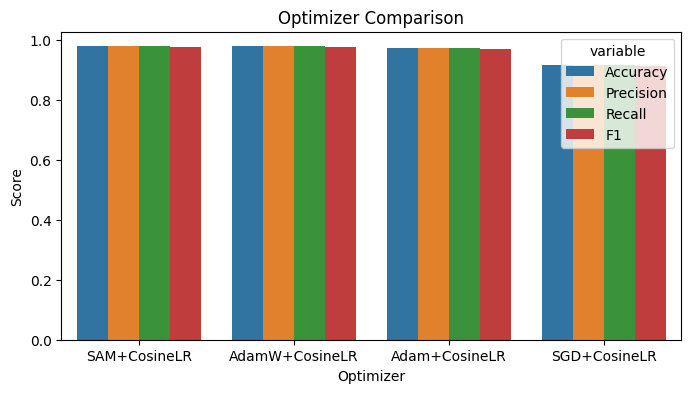

In [3]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Minimal Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
feature_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # label from first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = F.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = F.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                        torch.tensor(y_final, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# Training & Evaluation
# =========================
def train_and_evaluate(optimizer_name, model, optimizer, scheduler, criterion, epochs=30, patience=5):
    model = model.to(device)
    best_val_loss = float("inf")
    wait = 0
    best_path = f"best_{optimizer_name}.pth"

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()

            if isinstance(optimizer, SAM):
                # First step
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.first_step(zero_grad=True)
                # Second step
                criterion(model(xb), yb).backward()
                optimizer.second_step(zero_grad=True)
            else:
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        if scheduler is not None:
            scheduler.step()

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"[{optimizer_name}] Epoch {epoch+1} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), best_path)
        else:
            wait += 1
            if wait >= patience: break

    # Load best
    model.load_state_dict(torch.load(best_path))

    # Test
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    return {"Optimizer": optimizer_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

# =========================
# Run Comparisons
# =========================
results = []
criterion = Poly1LossWithSmoothing(num_classes=len(CLASS_NAMES))

# 1. SAM + CosineLR
model = ViTHead(X_final.shape[1], len(CLASS_NAMES))
base_optimizer = torch.optim.Adam
sam_opt = SAM(model.parameters(), base_optimizer, lr=1e-4)
scheduler_sam = torch.optim.lr_scheduler.CosineAnnealingLR(sam_opt.base_optimizer, T_max=50)
results.append(train_and_evaluate("SAM+CosineLR", model, sam_opt, scheduler_sam, criterion))

# 2. AdamW + CosineLR
model = ViTHead(X_final.shape[1], len(CLASS_NAMES))
adamw = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_adamw = torch.optim.lr_scheduler.CosineAnnealingLR(adamw, T_max=50)
results.append(train_and_evaluate("AdamW+CosineLR", model, adamw, scheduler_adamw, criterion))

# 3. Adam + CosineLR
model = ViTHead(X_final.shape[1], len(CLASS_NAMES))
adam = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler_adam = torch.optim.lr_scheduler.CosineAnnealingLR(adam, T_max=50)
results.append(train_and_evaluate("Adam+CosineLR", model, adam, scheduler_adam, criterion))

# 4. SGD + CosineLR
model = ViTHead(X_final.shape[1], len(CLASS_NAMES))
sgd = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
scheduler_sgd = torch.optim.lr_scheduler.CosineAnnealingLR(sgd, T_max=50)
results.append(train_and_evaluate("SGD+CosineLR", model, sgd, scheduler_sgd, criterion))

# =========================
# Results Table
# =========================
import pandas as pd
df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(df)

plt.figure(figsize=(8,4))
sns.barplot(df.melt(id_vars="Optimizer", value_vars=["Accuracy","Precision","Recall","F1"]),
            x="Optimizer", y="value", hue="variable")
plt.title("Optimizer Comparison")
plt.ylabel("Score")
plt.show()


Final Comparison:
        Optimizer  Accuracy  Precision    Recall        F1
0    SAM+CosineLR  0.978333   0.978481  0.978333  0.978203
1  AdamW+CosineLR  0.978333   0.978668  0.978333  0.978269
2   Adam+CosineLR  0.971667   0.971827  0.971667  0.971572
3    SGD+CosineLR  0.915000   0.916850  0.915000  0.912391


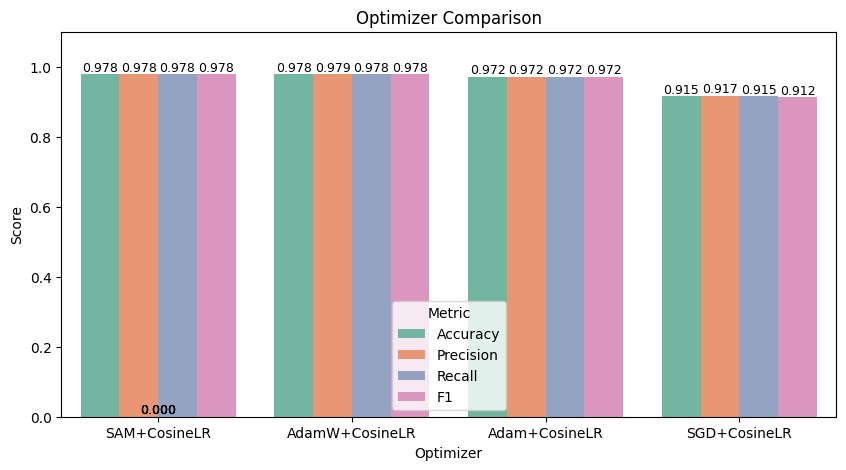

In [4]:
df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(df)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    df.melt(id_vars="Optimizer", value_vars=["Accuracy","Precision","Recall","F1"]),
    x="Optimizer", y="value", hue="variable", palette="Set2"
)
plt.title("Optimizer Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)  # keep space for text above bars

# Annotate bars with values
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.3f}",                # 3 decimal places
                (p.get_x() + p.get_width()/2., value),
                ha='center', va='bottom',
                fontsize=9, color='black', rotation=0)

plt.legend(title="Metric")
plt.show()